<a href="https://colab.research.google.com/github/kasrasa/Object-detection-tutorial/blob/Faster-RCNN/Faster_RCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision

print("Torch version:", torch.__version__)
print("TorchVision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.11.0+cpu
TorchVision version: 0.26.0+cpu
CUDA available: False
Using device: cpu


In [ ]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.ops import box_iou

from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import OrderedDict

def print_tensor_info(name, x):
    """
    Small helper to print tensor shape, dtype, device, min, and max.
    """
    if isinstance(x, torch.Tensor):
        print(f"{name}")
        print(f"  shape: {tuple(x.shape)}")
        print(f"  dtype: {x.dtype}")
        print(f"  device: {x.device}")
        print(f"  min/max: {x.min().item():.4f} / {x.max().item():.4f}")
    else:
        print(f"{name}: {type(x)}")


def show_image_with_boxes(image, boxes=None, scores=None, labels=None, title=None, max_boxes=10):
    """
    image: PIL image
    boxes: Tensor[N, 4] in xyxy format
    """
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image)

    if boxes is not None:
        boxes = boxes.detach().cpu()
        n = min(len(boxes), max_boxes)

        for i in range(n):
            x1, y1, x2, y2 = boxes[i].tolist()
            w = x2 - x1
            h = y2 - y1

            rect = patches.Rectangle(
                (x1, y1),
                w,
                h,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rect)

            text = ""
            if labels is not None:
                text += f"class={int(labels[i])}"
            if scores is not None:
                text += f" score={float(scores[i]):.2f}"

            if text:
                ax.text(
                    x1,
                    y1,
                    text,
                    bbox=dict(facecolor="white", alpha=0.7),
                    fontsize=9
                )

    if title:
        ax.set_title(title)

    ax.axis("off")
    plt.show()

Original image type: <class 'PIL.Image.Image'>
Original image size: (1546, 1213)


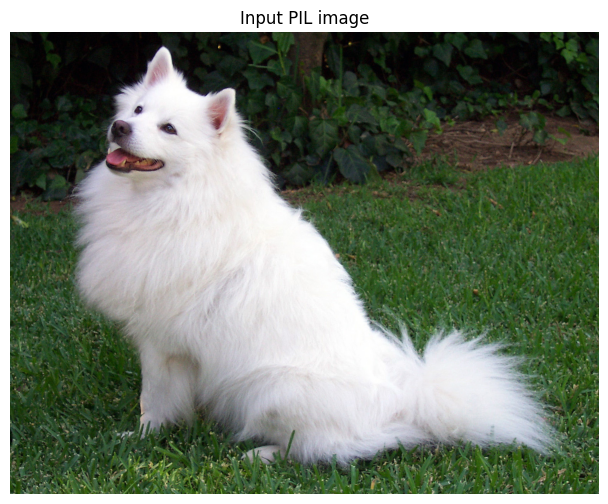

In [ ]:
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

print("Original image type:", type(image))
print("Original image size:", image.size)  # width, height

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input PIL image")
plt.show()

In [ ]:
image_tensor = torchvision.transforms.functional.to_tensor(image)

images = [image_tensor.to(device)]

print("Number of images:", len(images))
print_tensor_info("images[0]", images[0])

Number of images: 1
images[0]
  shape: (3, 1213, 1546)
  dtype: torch.float32
  device: cpu
  min/max: 0.0000 / 1.0000


In [ ]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = fasterrcnn_resnet50_fpn(weights=weights)
model = model.to(device)
model.eval()

categories = weights.meta["categories"]

print("Number of COCO classes:", len(categories))
print("First 10 categories:", categories[:10])

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 154MB/s]


Number of COCO classes: 91
First 10 categories: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']


Type of outputs: <class 'list'>
Number of outputs: 1
Keys in outputs[0]: dict_keys(['boxes', 'labels', 'scores'])
final boxes
  shape: (4, 4)
  dtype: torch.float32
  device: cpu
  min/max: 45.0133 / 1471.7245
final labels
  shape: (4,)
  dtype: torch.int64
  device: cpu
  min/max: 17.0000 / 34.0000
final scores
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min/max: 0.1133 / 0.9669

Top detections:
0 label_id: 18 label_name: dog score: 0.9668606519699097 box: [ 137.84052   67.79939 1386.9043  1172.8247 ]
1 label_id: 17 label_name: cat score: 0.3522205948829651 box: [ 134.8363   45.0133 1471.7245 1203.308 ]
2 label_id: 34 label_name: frisbee score: 0.3132008910179138 box: [253.01883 306.1613  406.6772  365.1062 ]
3 label_id: 18 label_name: dog score: 0.11326699703931808 box: [130.7382    62.592003 993.04926  874.35486 ]


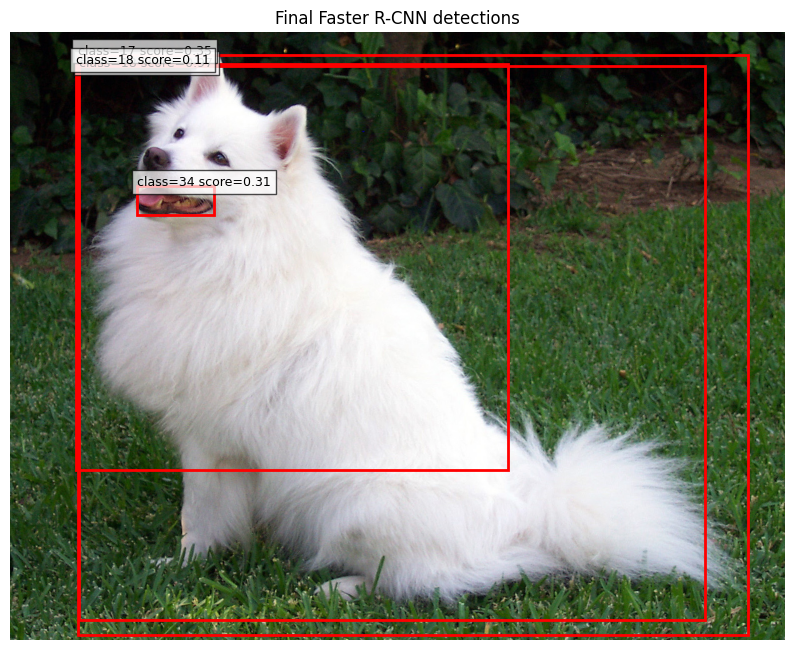

In [ ]:
with torch.no_grad():
    outputs = model(images)

print("Type of outputs:", type(outputs))
print("Number of outputs:", len(outputs))
print("Keys in outputs[0]:", outputs[0].keys())

boxes = outputs[0]["boxes"]
labels = outputs[0]["labels"]
scores = outputs[0]["scores"]

print_tensor_info("final boxes", boxes)
print_tensor_info("final labels", labels)
print_tensor_info("final scores", scores)

top_k = 5
print("\nTop detections:")
for i in range(min(top_k, len(boxes))):
    class_id = labels[i].item()
    print(
        i,
        "label_id:", class_id,
        "label_name:", categories[class_id],
        "score:", scores[i].item(),
        "box:", boxes[i].detach().cpu().numpy()
    )

show_image_with_boxes(
    image,
    boxes=boxes,
    scores=scores,
    labels=labels,
    title="Final Faster R-CNN detections",
    max_boxes=5
)

In [ ]:
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
with torch.no_grad():
    transformed_images, targets = model.transform(images, targets=None)

print("Original image size:", image.size)
print("Transformed batch tensor:")
print_tensor_info("transformed_images.tensors", transformed_images.tensors)

print("\nImage sizes after transform:")
print(transformed_images.image_sizes)

Original image size: (1546, 1213)
Transformed batch tensor:
transformed_images.tensors
  shape: (1, 3, 800, 1024)
  dtype: torch.float32
  device: cpu
  min/max: -2.1179 / 2.6400

Image sizes after transform:
[(800, 1019)]


In [ ]:
with torch.no_grad():
    features = model.backbone(transformed_images.tensors)

print("Type of features:", type(features))

for name, feat in features.items():
    print_tensor_info(f"feature map {name}", feat)

Type of features: <class 'collections.OrderedDict'>
feature map 0
  shape: (1, 256, 200, 256)
  dtype: torch.float32
  device: cpu
  min/max: -6.3973 / 6.6456
feature map 1
  shape: (1, 256, 100, 128)
  dtype: torch.float32
  device: cpu
  min/max: -6.7340 / 5.7984
feature map 2
  shape: (1, 256, 50, 64)
  dtype: torch.float32
  device: cpu
  min/max: -5.6427 / 7.2038
feature map 3
  shape: (1, 256, 25, 32)
  dtype: torch.float32
  device: cpu
  min/max: -6.9431 / 8.0131
feature map pool
  shape: (1, 256, 13, 16)
  dtype: torch.float32
  device: cpu
  min/max: -6.6543 / 7.3603


In [ ]:
with torch.no_grad():
    anchors = model.rpn.anchor_generator(transformed_images, list(features.values()))

print("Number of images:", len(anchors))
print_tensor_info("anchors[0]", anchors[0])

print("\nFirst 5 anchors:")
print(anchors[0][:5])

Number of images: 1
anchors[0]
  shape: (204624, 4)
  dtype: torch.float32
  device: cpu
  min/max: -362.0000 / 1322.0000

First 5 anchors:
tensor([[-23., -11.,  23.,  11.],
        [-16., -16.,  16.,  16.],
        [-11., -23.,  11.,  23.],
        [-19., -11.,  27.,  11.],
        [-12., -16.,  20.,  16.]])


In [ ]:
with torch.no_grad():
    objectness, pred_bbox_deltas = model.rpn.head(list(features.values()))

print("Number of feature levels:", len(objectness))

for i, (obj, delta) in enumerate(zip(objectness, pred_bbox_deltas)):
    print(f"\nFeature level {i}")
    print_tensor_info("objectness logits", obj)
    print_tensor_info("bbox deltas", delta)

Number of feature levels: 5

Feature level 0
objectness logits
  shape: (1, 3, 200, 256)
  dtype: torch.float32
  device: cpu
  min/max: -35.9433 / -0.2934
bbox deltas
  shape: (1, 12, 200, 256)
  dtype: torch.float32
  device: cpu
  min/max: -1.7111 / 1.3016

Feature level 1
objectness logits
  shape: (1, 3, 100, 128)
  dtype: torch.float32
  device: cpu
  min/max: -28.6643 / 5.9783
bbox deltas
  shape: (1, 12, 100, 128)
  dtype: torch.float32
  device: cpu
  min/max: -0.8716 / 0.8386

Feature level 2
objectness logits
  shape: (1, 3, 50, 64)
  dtype: torch.float32
  device: cpu
  min/max: -20.1738 / -2.2007
bbox deltas
  shape: (1, 12, 50, 64)
  dtype: torch.float32
  device: cpu
  min/max: -0.8230 / 0.9808

Feature level 3
objectness logits
  shape: (1, 3, 25, 32)
  dtype: torch.float32
  device: cpu
  min/max: -13.5914 / 1.3769
bbox deltas
  shape: (1, 12, 25, 32)
  dtype: torch.float32
  device: cpu
  min/max: -0.8633 / 0.8398

Feature level 4
objectness logits
  shape: (1, 3, 13,

In [ ]:
with torch.no_grad():
    proposals, rpn_losses = model.rpn(
        transformed_images,
        features,
        targets=None
    )

print("Number of proposal sets:", len(proposals))
print_tensor_info("proposals[0]", proposals[0])

print("RPN losses during eval mode:", rpn_losses)

print("\nFirst 5 proposals:")
print(proposals[0][:5])

Number of proposal sets: 1
proposals[0]
  shape: (1000, 4)
  dtype: torch.float32
  device: cpu
  min/max: 0.0000 / 1019.0000
RPN losses during eval mode: {}

First 5 proposals:
tensor([[  62.1605,   18.2188,  678.7491,  659.5138],
        [  26.4937,  100.8503,  901.5793,  800.0000],
        [  52.4068,  328.4092,  927.4324,  800.0000],
        [ 219.9318,  207.5709, 1000.8058,  800.0000],
        [ 136.6408,  278.5034,  809.7950,  783.6260]])


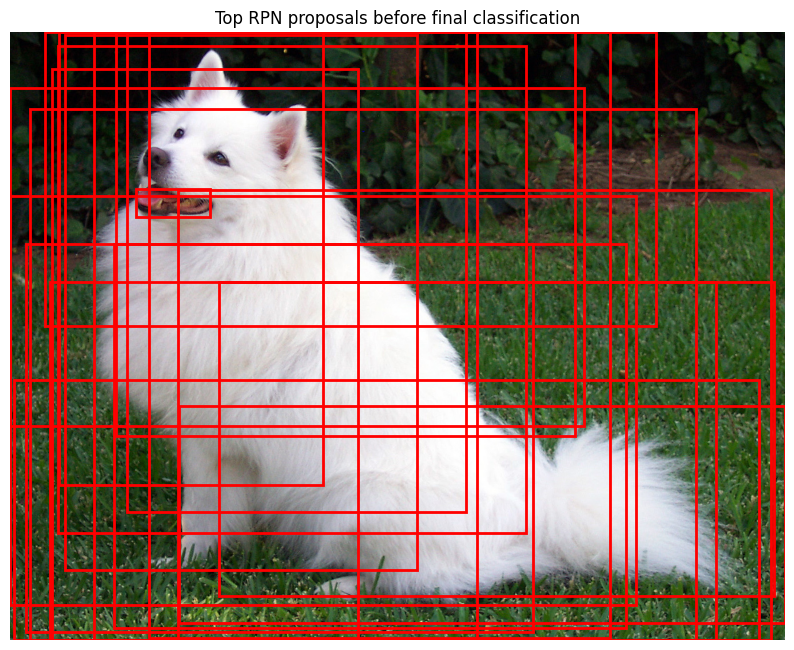

In [ ]:
reshaped_boxes = model.transform.postprocess([{"boxes": proposals[0]}], transformed_images.image_sizes, [image.size[::-1]])

show_image_with_boxes(
    image,
    boxes=reshaped_boxes[0]["boxes"],
    title="Top RPN proposals before final classification",
    max_boxes=20
)

In [ ]:
with torch.no_grad():
    detections, detector_losses = model.roi_heads(
        features,
        proposals,
        transformed_images.image_sizes,
        targets=None
    )

print("Before postprocessing:")
print("Number of detection sets:", len(detections))
print("Keys:", detections[0].keys())

print_tensor_info("roi boxes", detections[0]["boxes"])
print_tensor_info("roi labels", detections[0]["labels"])
print_tensor_info("roi scores", detections[0]["scores"])

Before postprocessing:
Number of detection sets: 1
Keys: dict_keys(['boxes', 'labels', 'scores'])
roi boxes
  shape: (4, 4)
  dtype: torch.float32
  device: cpu
  min/max: 29.6873 / 970.0435
roi labels
  shape: (4,)
  dtype: torch.int64
  device: cpu
  min/max: 17.0000 / 34.0000
roi scores
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min/max: 0.1133 / 0.9669


After postprocessing back to original image size:
final boxes
  shape: (4, 4)
  dtype: torch.float32
  device: cpu
  min/max: 45.0133 / 1471.7245
final labels
  shape: (4,)
  dtype: torch.int64
  device: cpu
  min/max: 17.0000 / 34.0000
final scores
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min/max: 0.1133 / 0.9669


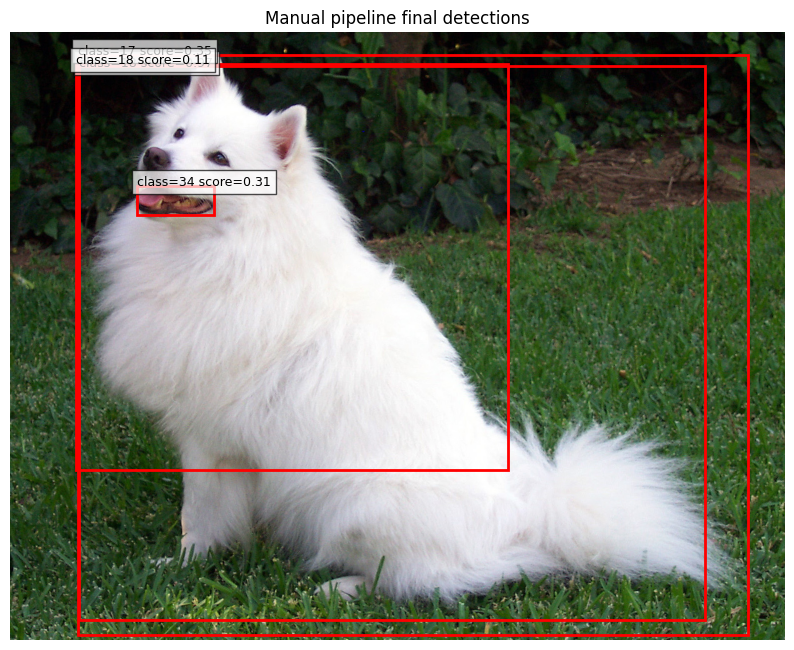

In [ ]:
with torch.no_grad():
    final_detections = model.transform.postprocess(
        detections,
        transformed_images.image_sizes,
        [image_tensor.shape[-2:]]
    )

print("After postprocessing back to original image size:")
print_tensor_info("final boxes", final_detections[0]["boxes"])
print_tensor_info("final labels", final_detections[0]["labels"])
print_tensor_info("final scores", final_detections[0]["scores"])

show_image_with_boxes(
    image,
    boxes=final_detections[0]["boxes"],
    scores=final_detections[0]["scores"],
    labels=final_detections[0]["labels"],
    title="Manual pipeline final detections",
    max_boxes=5
)

High-confidence detections: 1
High confidence bb coordinates: tensor([ 137.8405,   67.7994, 1386.9043, 1172.8247])
pseudo_gt_boxes
  shape: (1, 4)
  dtype: torch.float32
  device: cpu
  min/max: 67.7994 / 1386.9043


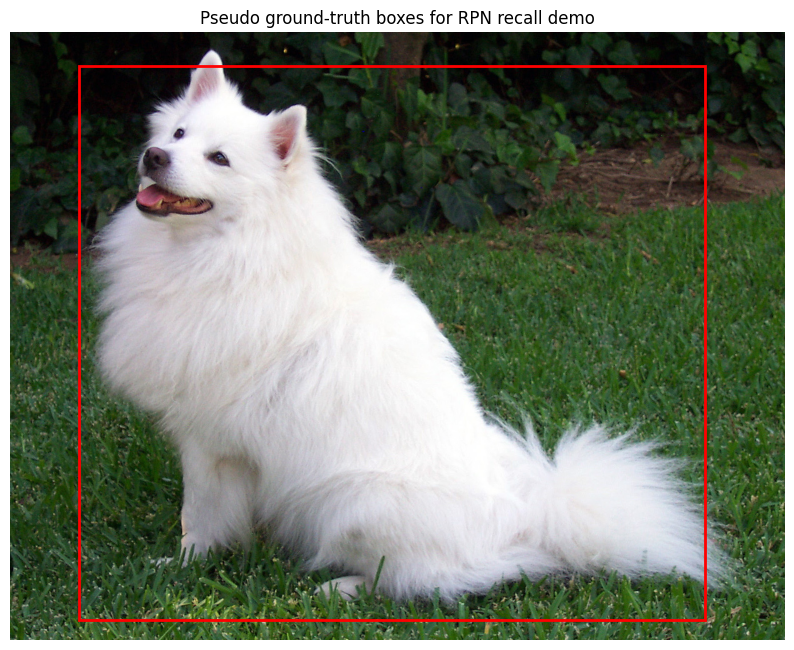

In [ ]:
confidence_threshold = 0.8
scores = final_detections[0]["scores"]
boxes = final_detections[0]["boxes"]

high_conf_indices = torch.where(scores > confidence_threshold)[0]

print("High-confidence detections:", len(high_conf_indices))
print("High confidence bb coordinates:", boxes[high_conf_indices[0]])

pseudo_gt_boxes = boxes[high_conf_indices[:3]].detach()

print_tensor_info("pseudo_gt_boxes", pseudo_gt_boxes)

show_image_with_boxes(
    image,
    boxes=pseudo_gt_boxes,
    title="Pseudo ground-truth boxes for RPN recall demo",
    max_boxes=3
)

In [ ]:
def proposal_recall_at_iou(gt_boxes, proposal_boxes, iou_threshold=0.5):
    """
    gt_boxes: Tensor[G, 4]
    proposal_boxes: Tensor[P, 4]

    Returns:
      recall: fraction of GT boxes covered by at least one proposal
      max_iou_per_gt: best IoU each GT box got from any proposal
    """
    if len(gt_boxes) == 0:
        return None, None

    ious = box_iou(gt_boxes, proposal_boxes)

    max_iou_per_gt = ious.max(dim=1).values
    matched = max_iou_per_gt >= iou_threshold
    recall = matched.float().mean().item()

    return recall, max_iou_per_gt

print(len(pseudo_gt_boxes), len(proposals[0]))
for threshold in [0.35, 0.4, 0.7, 0.9]:
    recall, max_iou_per_gt = proposal_recall_at_iou(
        pseudo_gt_boxes.to(device),
        reshaped_boxes[0]["boxes"],
        iou_threshold=threshold
    )

    print(f"IoU threshold {threshold}: RPN proposal recall = {recall:.3f}")
    print("Max IoU per pseudo-GT:", max_iou_per_gt.detach().cpu().numpy())

1 1000
IoU threshold 0.35: RPN proposal recall = 1.000
Max IoU per pseudo-GT: [0.81823766]
IoU threshold 0.4: RPN proposal recall = 1.000
Max IoU per pseudo-GT: [0.81823766]
IoU threshold 0.7: RPN proposal recall = 1.000
Max IoU per pseudo-GT: [0.81823766]
IoU threshold 0.9: RPN proposal recall = 0.000
Max IoU per pseudo-GT: [0.81823766]


In [ ]:
proposal_boxes = reshaped_boxes[0]["boxes"]

for k in [10, 50, 100, 300, 1000]:
    topk_props = proposal_boxes[:k]

    recall, max_iou_per_gt = proposal_recall_at_iou(
        pseudo_gt_boxes.to(device),
        topk_props,
        iou_threshold=0.8
    )

    print(f"Top {k:4d} proposals | Recall@0.5 = {recall:.3f}")

Top   10 proposals | Recall@0.5 = 1.000
Top   50 proposals | Recall@0.5 = 1.000
Top  100 proposals | Recall@0.5 = 1.000
Top  300 proposals | Recall@0.5 = 1.000
Top 1000 proposals | Recall@0.5 = 1.000


Best IoU per pseudo-GT:
[0.81823766]


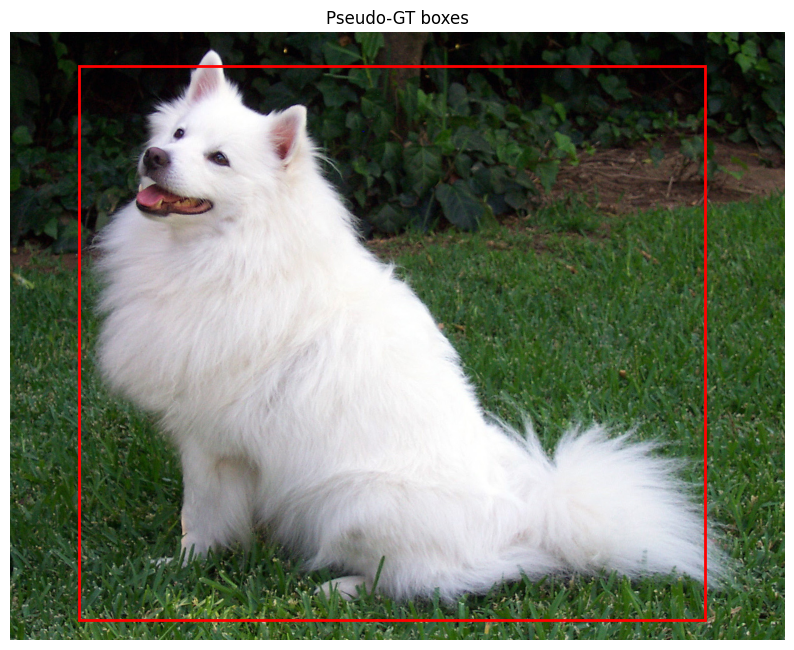

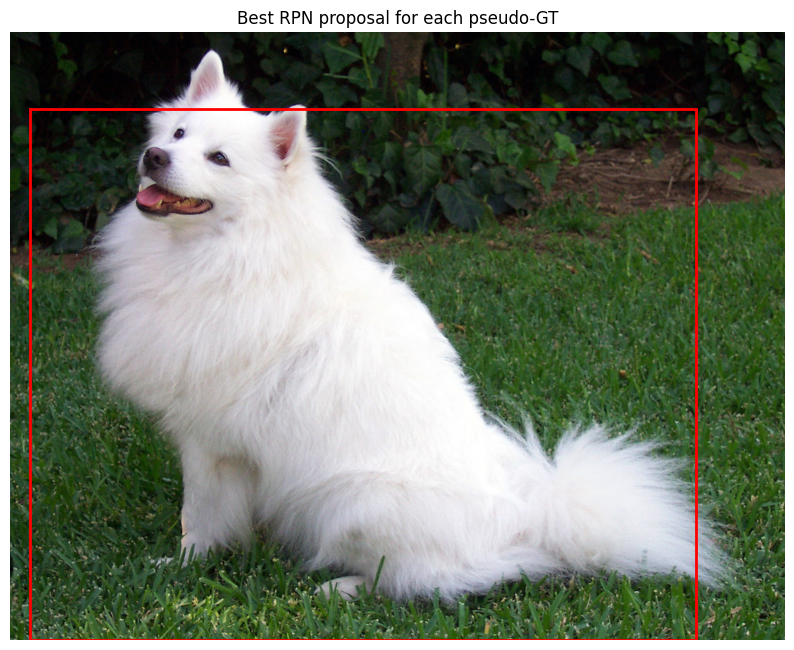

In [ ]:
gt_boxes = pseudo_gt_boxes.to(device)
proposal_boxes = reshaped_boxes[0]["boxes"]

ious = box_iou(gt_boxes, proposal_boxes)

best_iou, best_idx = ious.max(dim=1)
best_proposals = proposal_boxes[best_idx]

print("Best IoU per pseudo-GT:")
print(best_iou.detach().cpu().numpy())

show_image_with_boxes(
    image,
    boxes=gt_boxes.detach().cpu(),
    title="Pseudo-GT boxes",
    max_boxes=3
)

show_image_with_boxes(
    image,
    boxes=best_proposals.detach().cpu(),
    title="Best RPN proposal for each pseudo-GT",
    max_boxes=3
)

In [ ]:
target_boxes = pseudo_gt_boxes.detach().to(device)
target_labels = labels[high_conf_indices[:len(target_boxes)]].detach().to(device)

target = {
    "boxes": target_boxes,
    "labels": target_labels
}

targets = [target]

print("Training target:")
print_tensor_info("target boxes", targets[0]["boxes"])
print_tensor_info("target labels", targets[0]["labels"])

print("Labels:")
for class_id in target_labels.detach().cpu().tolist():
    print(class_id, categories[class_id])

Training target:
target boxes
  shape: (1, 4)
  dtype: torch.float32
  device: cpu
  min/max: 67.7994 / 1386.9043
target labels
  shape: (1,)
  dtype: torch.int64
  device: cpu
  min/max: 18.0000 / 18.0000
Labels:
18 dog


In [ ]:
model.train()

loss_dict = model(images, targets)

print("Loss dict keys:")
print(loss_dict.keys())

for name, value in loss_dict.items():
    print(f"{name}: {value.item():.4f}")

total_loss = sum(loss for loss in loss_dict.values())
print("Total loss:", total_loss.item())

model.eval()

Loss dict keys:
dict_keys(['loss_classifier', 'loss_box_reg', 'loss_objectness', 'loss_rpn_box_reg'])
loss_classifier: 0.0133
loss_box_reg: 0.0181
loss_objectness: 0.0092
loss_rpn_box_reg: 0.0171
Total loss: 0.057688646018505096


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
for name, param in model.backbone.named_parameters():
    param.requires_grad = False

trainable_params = [p for p in model.parameters() if p.requires_grad]
frozen_params = [p for p in model.parameters() if not p.requires_grad]

print("Trainable parameter tensors:", len(trainable_params))
print("Frozen parameter tensors:", len(frozen_params))

Trainable parameter tensors: 14
Frozen parameter tensors: 69


In [ ]:
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0005
)

In [ ]:
def train_one_epoch(model, optimizer, dataloader, device):
    model.train()

    total_loss_value = 0.0

    for step, batch in enumerate(dataloader):
        images, targets = batch

        images = [img.to(device) for img in images]
        targets = [
            {
                "boxes": t["boxes"].to(device),
                "labels": t["labels"].to(device)
            }
            for t in targets
        ]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss_value += loss.item()

        print(f"step={step}, loss={loss.item():.4f}")

    avg_loss = total_loss_value / len(dataloader)
    return avg_loss

# Run the faster RCNN on a coco dataset and evaluate performance on small objects

In [ ]:
!pip install -q pycocotools

In [48]:
import os
import json
import random
import time
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import functional as F
from pycocotools.coco import COCO
from torchvision.ops import box_iou

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
def box_area_xyxy(boxes):
    """
    boxes: Tensor[N, 4]
    """
    widths = (boxes[:, 2] - boxes[:, 0]).clamp(min=0)
    heights = (boxes[:, 3] - boxes[:, 1]).clamp(min=0)
    return widths * heights


def coco_size_bucket_from_area(area):
    """
    COCO convention:
      small: area < 32^2
      medium: 32^2 <= area < 96^2
      large: area >= 96^2
    """
    if area < 32**2:
        return "small"
    elif area < 96**2:
        return "medium"
    else:
        return "large"

In [46]:
TRAIN_ANN = "/content/data/train/instances_train2014.json"
VAL_ANN   = "/content/data/valid/instances_val2014.json"

print("train ann exists:", os.path.exists(TRAIN_ANN))
print("val ann exists:", os.path.exists(VAL_ANN))

train ann exists: True
val ann exists: True


In [49]:
ann_path = VAL_ANN
coco = COCO(ann_path)

print("Number of images:", len(coco.imgs))
print("Number of annotations:", len(coco.anns))
print("Number of categories:", len(coco.cats))

cats = coco.loadCats(coco.getCatIds())
print("First 10 categories:")
for c in cats[:10]:
    print(c)

loading annotations into memory...
Done (t=4.84s)
creating index...
index created!
Number of images: 40504
Number of annotations: 291875
Number of categories: 80
First 10 categories:
{'supercategory': 'person', 'id': 1, 'name': 'person'}
{'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'}
{'supercategory': 'vehicle', 'id': 3, 'name': 'car'}
{'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'}
{'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'}
{'supercategory': 'vehicle', 'id': 6, 'name': 'bus'}
{'supercategory': 'vehicle', 'id': 7, 'name': 'train'}
{'supercategory': 'vehicle', 'id': 8, 'name': 'truck'}
{'supercategory': 'vehicle', 'id': 9, 'name': 'boat'}
{'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'}


In [50]:
one_img_id = list(coco.imgs.keys())[0]
one_img = coco.loadImgs(one_img_id)[0]

ann_ids = coco.getAnnIds(imgIds=[one_img_id], iscrowd=None)
anns = coco.loadAnns(ann_ids)

print("Image example:")
print(one_img)

print("\nNumber of annotations for this image:", len(anns))

if len(anns) > 0:
    print("\nAnnotation example:")
    print(anns[0])

Image example:
{'license': 3, 'file_name': 'COCO_val2014_000000391895.jpg', 'coco_url': 'http://images.cocodataset.org/val2014/COCO_val2014_000000391895.jpg', 'height': 360, 'width': 640, 'date_captured': '2013-11-14 11:18:45', 'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg', 'id': 391895}

Number of annotations for this image: 4

Annotation example:
{'segmentation': [[376.97, 176.91, 398.81, 176.91, 396.38, 147.78, 447.35, 146.17, 448.16, 172.05, 448.16, 178.53, 464.34, 186.62, 464.34, 192.28, 448.97, 195.51, 447.35, 235.96, 441.69, 258.62, 454.63, 268.32, 462.72, 276.41, 471.62, 290.98, 456.25, 298.26, 439.26, 292.59, 431.98, 308.77, 442.49, 313.63, 436.02, 316.86, 429.55, 322.53, 419.84, 354.89, 402.04, 359.74, 401.24, 312.82, 370.49, 303.92, 391.53, 299.87, 391.53, 280.46, 385.06, 278.84, 381.01, 278.84, 359.17, 269.13, 373.73, 261.85, 374.54, 256.19, 378.58, 231.11, 383.44, 205.22, 385.87, 192.28, 373.73, 184.19]], 'area': 12190.44565, 'iscrowd': 0, 

In [52]:
def valid_detection_ann(ann):
    """
    Keep annotations usable for object detection.
    """
    if ann.get("iscrowd", 0) == 1:
        return False

    x, y, w, h = ann["bbox"]

    if w <= 1 or h <= 1:
        return False

    if ann.get("area", w * h) <= 1:
        return False

    return True


def image_small_object_stats(coco, img_id):
    ann_ids = coco.getAnnIds(imgIds=[img_id], iscrowd=False)
    anns = coco.loadAnns(ann_ids)
    anns = [a for a in anns if valid_detection_ann(a)]

    small = []
    medium = []
    large = []

    for ann in anns:
        bucket = coco_size_bucket_from_area(ann["area"])
        if bucket == "small":
            small.append(ann)
        elif bucket == "medium":
            medium.append(ann)
        else:
            large.append(ann)

    return {
        "all": anns,
        "small": small,
        "medium": medium,
        "large": large
    }


small_object_image_ids = []

for img_id in coco.imgs.keys():
    stats = image_small_object_stats(coco, img_id)

    if len(stats["small"]) >= 3:
        small_object_image_ids.append(img_id)

print("Images with at least 3 small objects:", len(small_object_image_ids))

# show a few examples
for img_id in small_object_image_ids[:5]:
    img_info = coco.loadImgs(img_id)[0]
    stats = image_small_object_stats(coco, img_id)
    print(
        img_id,
        img_info["file_name"],
        "small:", len(stats["small"]),
        "medium:", len(stats["medium"]),
        "large:", len(stats["large"])
    )

Images with at least 3 small objects: 12144
184613 COCO_val2014_000000184613.jpg small: 15 medium: 5 large: 3
554625 COCO_val2014_000000554625.jpg small: 5 medium: 12 large: 2
397133 COCO_val2014_000000397133.jpg small: 10 medium: 6 large: 3
574769 COCO_val2014_000000574769.jpg small: 12 medium: 5 large: 2
309022 COCO_val2014_000000309022.jpg small: 6 medium: 0 large: 2
